# Impoting Libraries

In [739]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reading CSV Data

In [740]:
df = pd.read_csv("C:\\Users\\Admin\\OneDrive\\Desktop\\project\\p1\\data\\student_performance.csv")

# Check the Information

In [741]:
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [742]:
df.tail()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
999995,999996,18.0,95.5,4.8,100.0,A
999996,999997,15.7,82.7,6.7,88.3,A
999997,999998,14.2,85.1,5.8,87.9,A
999998,999999,25.3,90.0,5.3,100.0,A
999999,1000000,18.3,84.6,4.1,100.0,A


In [743]:
df.shape

(1000000, 6)

In [744]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  str    
dtypes: float64(4), int64(1), str(1)
memory usage: 45.8 MB


In [745]:
df.dtypes

student_id                   int64
weekly_self_study_hours    float64
attendance_percentage      float64
class_participation        float64
total_score                float64
grade                          str
dtype: object

# Chechikng the DataSet

In [746]:
duplicated_values = df.duplicated().sum()

In [747]:
missing_values = df.isna().sum().sum()

In [748]:
invalid_attendance = df[
    (df['attendance_percentage'] > 100) |
    (df['attendance_percentage'] < 0)
].shape[0]

In [749]:
invalid_weekly_hours = (df['weekly_self_study_hours'] < 0).sum()

In [750]:
invalid_score = df[
    (df['total_score'] < 0) |
    (df['total_score'] > 100)
].shape[0]

In [751]:
if (
    duplicated_values == 0 and
    missing_values == 0 and
    invalid_attendance == 0 and
    invalid_weekly_hours == 0 and 
    invalid_score == 0
):
    print('Data is cleaned')
else:
    print('Data needs to be clean')

    
print('=' * 40)
print('             DataSet Report')
print('=' * 40)

print(f'duplicated_values: {duplicated_values}')
print(f'missing_values: {missing_values}')
print(f'invalid_attendance: {invalid_attendance}')
print(f'invalid_score: {invalid_score}')
print(f'invalid_weekly_hours: {invalid_weekly_hours}')
print('=' * 40)


print('Data is ready for analysis')



Data is cleaned
             DataSet Report
duplicated_values: 0
missing_values: 0
invalid_attendance: 0
invalid_score: 0
invalid_weekly_hours: 0
Data is ready for analysis


In [752]:
df['attendance_percentage'].agg(['min','max', 'mean'])

min      50.000000
max     100.000000
mean     84.711046
Name: attendance_percentage, dtype: float64

In [753]:
df['weekly_self_study_hours'].agg(['min','max', 'mean'])

min      0.000000
max     40.000000
mean    15.029127
Name: weekly_self_study_hours, dtype: float64

In [754]:
df['class_participation'].agg(['min','max', 'mean'])

min      0.000000
max     10.000000
mean     5.985203
Name: class_participation, dtype: float64

In [755]:
df['total_score'].agg(['min','max', 'mean'])

min       9.400000
max     100.000000
mean     84.283845
Name: total_score, dtype: float64

# Feature Engineering

In [756]:
#creating new category columns
df['attendance_category'] = 0
df['study_hour_category'] = 0
df['performance_category'] = 0
df['participation_level'] = 0

In [757]:
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade,attendance_category,study_hour_category,performance_category,participation_level
0,1,18.5,95.6,3.8,97.9,A,0,0,0,0
1,2,14.0,80.0,2.5,83.9,B,0,0,0,0
2,3,19.5,86.3,5.3,100.0,A,0,0,0,0
3,4,25.7,70.2,7.0,100.0,A,0,0,0,0
4,5,13.4,81.9,6.9,92.0,A,0,0,0,0


In [758]:
def categorize_score(series):
    return np.select([
    (series >= 90) & (series <= 100),
    (series >= 75) & (series <= 89),
    (series >= 60) & (series <= 74),
    (series >= 0) & (series <= 59),
], 
[
    'Excellent',
    'Good',
    'Average',
    'Poor'
], default='Poor')

df['attendance_category'] = categorize_score(df['attendance_percentage'])

In [759]:
def study_categorize(series):
    return np.select([
    (series >= 20) & (series <= 40),
    (series >= 10) & (series <= 19),
    (series >= 5) & (series <= 9),
    (series >= 0) & (series <= 4),
], 
[
    'Excellent',
    'Good',
    'Average',
    'Poor'
], default='Poor')

df['study_hour_category'] = study_categorize(df['weekly_self_study_hours'])

In [760]:
def categorize_score(series):
    return np.select([
    (series >= 90) & (series <= 100),
    (series >= 75) & (series <= 89),
    (series >= 60) & (series <= 74),
    (series >= 0) & (series <= 59),
], 
[
    'Excellent',
    'Good',
    'Average',
    'Poor'
], default='Poor')

df['performance_category'] = categorize_score(df['total_score'])

In [761]:
def participation_lvl(series):
    return np.select([
    (series >= 0.0) & (series <= 4.7),
    (series >= 4.6) & (series <= 6.0),
    (series >= 5.9) & (series <= 7.3),
    (series >= 7.2) & (series <= 10.0),
], 
[
    'Low',
    'Moderate',
    'High',
    'Very High'
], default='Low')

df['participation_level'] = participation_lvl(df['class_participation'])

# Data_Analysis

## overall_statistic

In [799]:
def overall_statistics(df):
    return df.agg({
        'total_score': ['mean', 'max', 'min'],
        'attendance_percentage': ['mean'],
        'weekly_self_study_hours': ['mean']
    })

overall = overall_statistics(df)

## Categorical Analysis

In [763]:
def category_count(series, column):
    return df.groupby(series)[column].count()

category_count('performance_category', 'student_id')

performance_category
Average      168039
Excellent    451378
Good         263693
Poor         116890
Name: student_id, dtype: int64

In [764]:
def category_count(series, column):
    return df.groupby(series)[column].count()

category_count('attendance_category', 'student_id')

attendance_category
Average      130499
Excellent    310521
Good         499267
Poor          59713
Name: student_id, dtype: int64

In [765]:
def category_count(series, column):
    return df.groupby(series)[column].count()

category_count('study_hour_category', 'student_id')

study_hour_category
Average      122559
Excellent    239320
Good         482834
Poor         155287
Name: student_id, dtype: int64

## Relationships

In [766]:
def relation(series, column):
    return df.groupby(series)[column].mean().sort_values(ascending=False)

relation('performance_category', 'attendance_percentage')

performance_category
Poor         84.739988
Average      84.721339
Excellent    84.707024
Good         84.698541
Name: attendance_percentage, dtype: float64

In [767]:
def relation(series, column):
    return df.groupby(series)[column].mean().sort_values(ascending=False)

relation('study_hour_category', 'total_score')

study_hour_category
Excellent    98.545426
Good         85.673169
Poor         70.812960
Average      68.030115
Name: total_score, dtype: float64

In [768]:
def relation(series, column):
    return df.groupby(series)[column].mean().sort_values(ascending=False)

relation('participation_level', 'class_participation')

participation_level
Very High    8.478601
High         6.675517
Moderate     5.420279
Low          3.538858
Name: class_participation, dtype: float64

In [802]:
def grades_rel(series):
    return df.groupby(series).agg({
        'total_score': ['mean'],
        'attendance_percentage': ['mean'],
        'weekly_self_study_hours': ['mean']
    })

grd = grades_rel('grade')

## Top and Last Performers

In [770]:
sorted_df = df.sort_values('total_score', ascending=False)[['student_id', 'total_score', 'grade']]
top = sorted_df.head(10)
last = sorted_df.tail(10)
pd.concat([top, last])

,student_id,total_score,grade
3,4,100.0,A
2,3,100.0,A
466933,466934,100.0,A
466932,466933,100.0,A
466931,466932,100.0,A
466930,466931,100.0,A
466929,466930,100.0,A
466959,466960,100.0,A
466958,466959,100.0,A
466957,466958,100.0,A


# Visualisation using Pandas

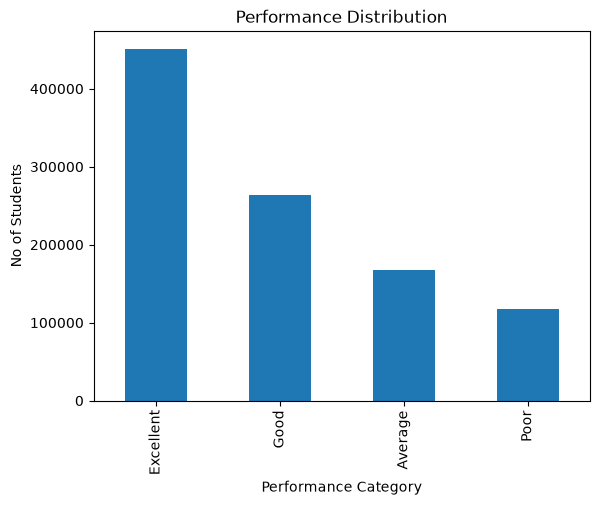

In [776]:
performance = df['performance_category'].value_counts()
performance.plot(kind='bar')

plt.title('Performance Distribution')
plt.xlabel('Performance Category')
plt.ylabel('No of Students')

plt.savefig('performance_distribution.png')
plt.show()

plt.close()

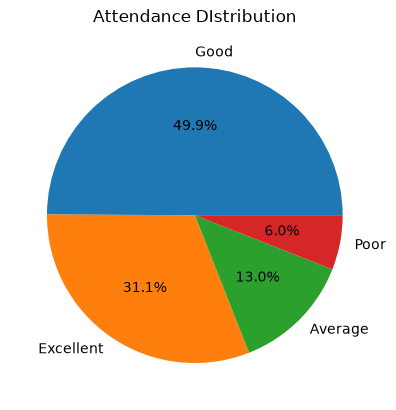

In [781]:
attendance = df['attendance_category'].value_counts()
plt.pie(
    attendance,
    labels=attendance.index,
    autopct='%1.1f%%'
)

plt.title('Attendance DIstribution')
plt.savefig('attendance_distribution.png')

plt.show()

plt.close()

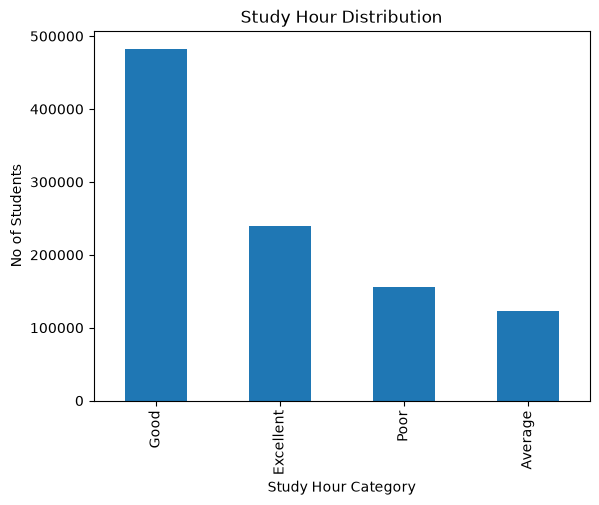

In [791]:
study_hour = df['study_hour_category'].value_counts()
study_hour.plot(kind='bar')

plt.title('Study Hour Distribution')
plt.xlabel('Study Hour Category')
plt.ylabel('No of Students')

plt.savefig('study_hour_distribution.png')
plt.show()

plt.close()

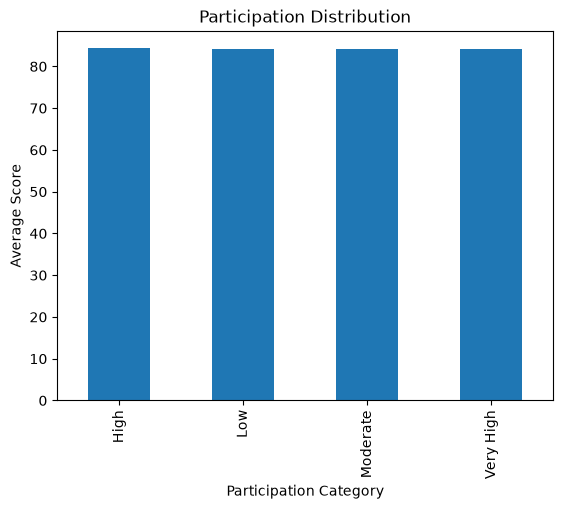

In [ ]:
participation = df.groupby('participation_level')['total_score'].mean()
participation.plot(kind='bar')

plt.title('Participation Distribution')
plt.xlabel('Participation Category')
plt.ylabel('Average Score')

plt.savefig('participation_distribution.png')
plt.show()

plt.close()

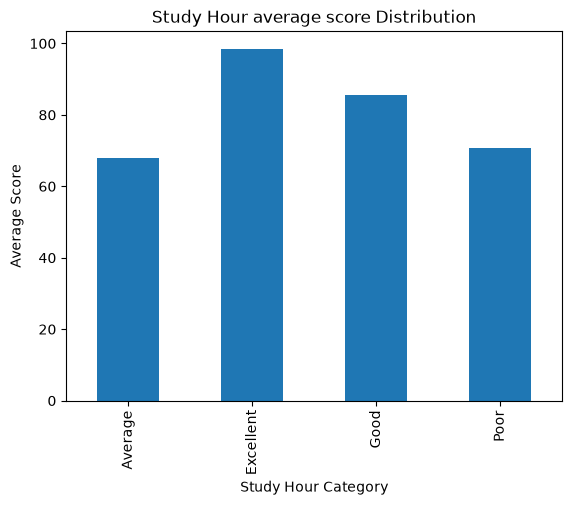

In [795]:
average_study = df.groupby('study_hour_category')['total_score'].mean()
average_study.plot(kind='bar')

plt.title('Study Hour average score Distribution')
plt.xlabel('Study Hour Category')
plt.ylabel('Average Score')

plt.savefig('average_study_distribution.png')
plt.show()

plt.close()

# Exporting Results

In [798]:
df.to_csv('cleaned_student_dataset.csv', index=False)

In [800]:
overall.to_csv('overall_statistics.csv', index=False)

In [804]:
grd.to_csv('grade_summary.csv', index=False)